# 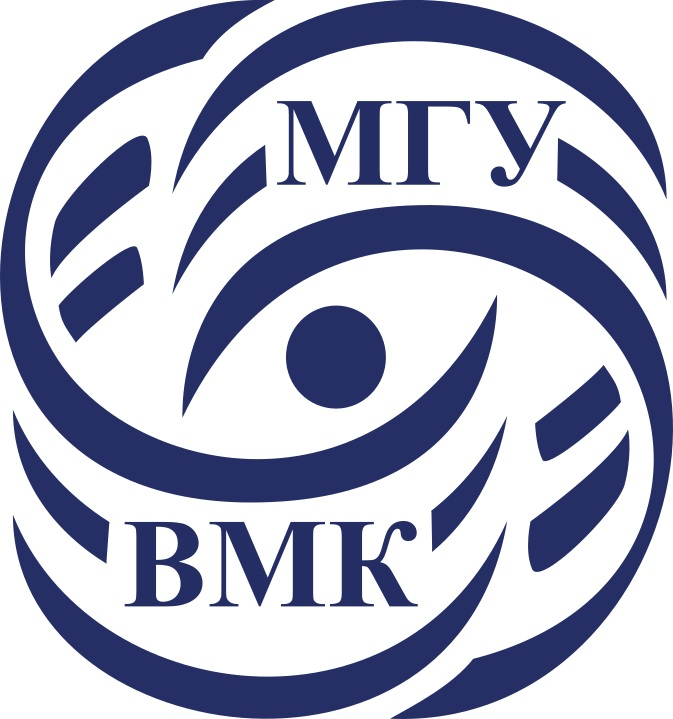

# Машинное обучение. ВМК МГУ

# Практическое задание 3: Линейные модели: регрессия

## Уровень: <font color='MediumSeaGreen'>**Исследовательский (Research)**</font>

# О формате сдачи

🔷 **<font color='plum'>При решении ноутбука используйте данный шаблон</font>**

    ✅ Можно добавлять новые ячейки любых типов
    ❌ Не нужно удалять текстовые ячейки c разметкой частей ноутбука и формулировками заданий


🔷 **<font color='plum'>При оценивании задач учитывается код</font>**

    ✅ Задания, в которых необходим код, обычно помечаются фразами "Your code here"/"Ваш код" и аналогичными
    ❌ Ответы на вопросы без сопутствующего кода оцениваются в 0 баллов
    ❌ Наличе работоспособного кода в ноутбуке, если на сказано иного, обязательно

🔷 **<font color='plum'>При оценивании задач учитываются выводы</font>**

    ✅ Задания, в которых необходимы выводы, обычно помечаются фразами Вывод"/"Ответ на вопрос"/"Ваш текст" и аналогичными
    ✅ Обычно выводы подразумевают под собой текстовый ответ (можно писать markdown, latex).
    ✅ Сопутствующие изображения, графики, таблички - приветствуются!
    ❌ При отсутствии выводов задание не засчитается на полный балл

-----------
<font color="white" style="opacity:0.2025"></font>







Цель данного задания:

* Узнать, что такое переобучение и как с ним бороться в линейных моделях;
* Понять, чем отличаются разные регуляризаторы;
* Научиться решать задачу регрессии линейными моделями.
-------
<font color=DarkOrange>**Примерное время выполнения (execution time/время выполнения, если нажать run all) всех ячеек ноутбука при правильной реализации: 7 минут </font>**

# Подготовка рабочей среды

Сначала установим нужные нам версии библиотек. Мы гарантируем, что в данных версиях задание будет корректно отрабатывать.

После установки нужных версий, **возможно,** нужно перезагрузить среду (runtime), но скорее всего вам это не понадобится


На скачивание файла и установку понадобится не более 5 минут.

<font color='OrangeRed'>**Важно!**</font>

Устанавливать нужные версии нужно каждый раз, когда создается новый рантайм. Например, если вы 2 часа подряд делаете это задание, то подготовить библиотеки достаточно 1 раз. Но если вы, например, начали в понедельник, затем закрыли/выключили ноутбук, то при продолжении в среду, вам нужно будет запустить рантайм заново и следовательно заново установить библиотеки.

<font color='OrangeRed'>**Важно!**</font>
Если вы предпочитаете делать практические задания на своем личном ноутбуке, то проверьте, что вы установили рабочее окружение в [соответствии с гайдом](https://github.com/MSU-ML-COURSE/ML-COURSE-24-25/blob/main/tutorials/%D0%A2%D1%83%D1%82%D0%BE%D1%80%D0%B8%D0%B0%D0%BB%20%D0%BF%D0%BE%20%D1%83%D1%81%D1%82%D0%B0%D0%BD%D0%BE%D0%B2%D0%BA%D0%B5%20%D1%80%D0%B0%D0%B1%D0%BE%D1%87%D0%B5%D0%B3%D0%BE%20%D0%BE%D0%BA%D1%80%D1%83%D0%B6%D0%B5%D0%BD%D0%B8%D1%8F%20%D0%B2%20Python%20%D0%B4%D0%BB%D1%8F%20%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D1%8F%20%D0%B7%D0%B0%D0%B4%D0%B0%D1%87%20(2).pdf)


In [131]:
! curl https://raw.githubusercontent.com/MSU-ML-COURSE/ML-COURSE-25-26/refs/heads/master/requirements/requirements.txt -o ./requirements_2025_26_for_colab_small.txt
! pip install -q -r ./requirements_2025_26_for_colab_small.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   360  100   360    0     0   1922      0 --:--:-- --:--:-- --:--:--  1925


Проверим версию библиотеки:

In [132]:
import catboost
assert(catboost.__version__ == '1.2.8')

Теперь можно приступать к выполнению задания! :)

-----------
<font color="white" style="opacity:0.2025"></font>

In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter("ignore")
sns.set(style="darkgrid")
%matplotlib inline

## Линейная регрессия и регуляризация

Напомним, что линейная регрессия — это модель следующего вида: $$a(x) = \langle w, x \rangle + b$$ где $w \in \mathbb{R}^d$, $b \in \mathbb{R}$. Обучить линейную регрессию — значит найти $w$ и $b$.

В модели линейной регрессии с $l_2$ регуляризацией мы оптимизируем следующий функционал:

$\frac{1}{N} \cdot ∑_{i=1}^M (w_1 \cdot x_{i1} + \dots w_n \cdot x_{in} + b - y_i)^2 + \frac{\alpha}{2} \cdot \left( w_1^2 + \dots + w_n^2 \right) \rightarrow \min_{w_1, \dots, w_n, b}$

В модели линейной регрессии с $l_1$ регуляризацией мы оптимизируем следующий функционал:

$\frac{1}{N} \cdot ∑_{i=1}^M (w_1 \cdot x_{i1} + \dots w_n \cdot x_{in} + b - y_i)^2 + \alpha \cdot \left( |w_1| + \dots + |w_n| \right) \rightarrow \min_{w_1, \dots, w_n, b}$

### <font color='DarkOrange'>**Задание 1 [1 балл]**</font>

Почему при обучении линейных моделей, коэффициент $b$ не регуляризуется? Дайте ответ с опорой на лекции. Возможно вам также поможет картика из базовой части

<font color='MediumOrchid'>**Ваши выводы тут:**</font> В регуляризации мы хотим уменьшить сумму модулей/квадратов весов. То есть мы пытаемся сделать веса поменьше. Коэффициент b отвечает за смещение прямой (гиперплоскости) вдоль Oy. Если мы будем пытаться регуляризовать b, то будем накладывать на b ограничение. Будем штрафовать модель за то, что прямая не проходит через ноль. Для произвольных данных это не имеет смысла. Они могут лежать на одной прямой y=kx+100, но мы будем пытаться минимизировать b.

-----
<font color="white" style="opacity:0.2025"></font>

Рассмотрим модель линейной регрессии с $l_2$ регуляризацией. В sklearn эта модель реализована посредством класса Ridge. В нём есть методы fit и predict. Первый принимает на вход обучающую выборку и вектор целевых переменных и обучает модель, второй, будучи вызванным после обучения модели, возвращает предсказание на выборке.

Сгенерируем случайные данные. Пусть $x$ будет обычным числом из равномерного распределения, а $𝑦=0.5 \cdot x + 0.1$ &mdash; целевая переменная. При этом наблюдаем мы $\overline{y} = y + \varepsilon,~\varepsilon \sim N(0, 0.01)$. Добавим в данные к переменной $x$ её же умноженную на $3$. То есть, теперь у нас два признака $x_1$ и $x_2 = 3 \cdot x_1$.

Поскольку  $y = c \cdot 0.5 \cdot x_1 + \frac{1 - c}{6} \cdot x_2 + 0.1$, где $c$ любое сколь угодно большое вещественное число. То, как мы могли убедиться в базовой части, без регуляризации есть риск выучить очень большие веса.

Посмотрим, как меняется значения весов, в зависимости от значения коэффициента регуляризации.

In [134]:
from sklearn.linear_model import Ridge

In [135]:
np.random.seed(1)
X = np.random.uniform(0, 1, 100)
Y = X * 0.5 + 0.1 + np.random.randn(100) * 0.1

X3 = np.hstack((X[:, None], 3 * X[:, None]))
Y3 = X3[:, 0] * 0.5 + 0.1 + np.random.randn(100) * 0.1

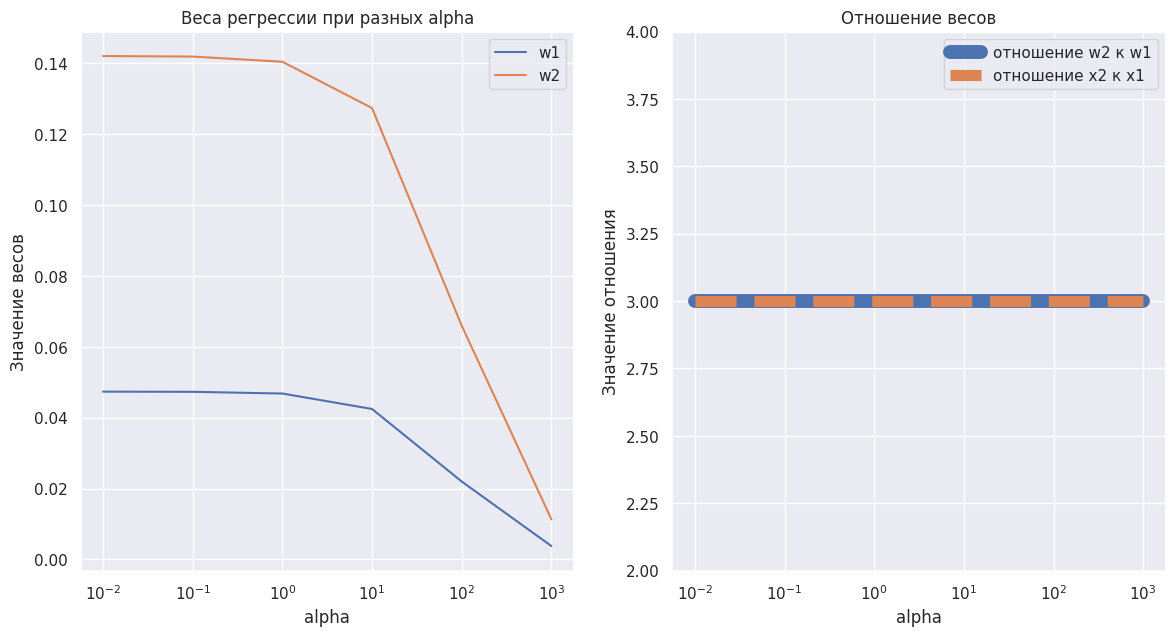

In [136]:
w1 = []
w2 = []

alphas = [0.01, 0.1, 1, 10, 100, 1000]

for alpha in alphas:
    reg = Ridge(alpha=alpha)
    reg.fit(X3, Y3)
    w1.append(reg.coef_[0])
    w2.append(reg.coef_[1])

w1 = np.array(w1)
w2 = np.array(w2)

fig, axs = plt.subplots(figsize=(14, 7), ncols=2)
axs[0].plot(alphas, w1, label="w1")
axs[0].plot(alphas, w2, label="w2")
axs[0].set_xscale("log")
axs[0].set_title("Веса регрессии при разных alpha")
axs[0].set_xlabel("alpha")
axs[0].set_ylabel("Значение весов")
axs[0].legend()
axs[1].plot(alphas, w2 / w1, label="отношение w2 к w1", linewidth=10)
axs[1].plot([0.01, 1000], [3, 3], label="отношение x2 к x1", linestyle="--", linewidth=8)
axs[1].set_xscale("log")
axs[1].set_ylim(2,4)
axs[1].set_xlabel("alpha")
axs[1].set_ylabel("Значение отношения")
axs[1].set_title("Отношение весов")
axs[1].legend()
plt.show()

### <font color='DarkOrange'>**Задание 2 [2 баллa]**</font>

Как думаете, почему отношение между весами постоянно? (подсказка, необходимо выписать функцию потерь и посчитать производные по весам)

<font color='MediumOrchid'>**Ваши выводы тут:**</font>

$L = \frac{1}{N}\sum_{i=1}^{M}(w_1 x_{i1} + w_2 x_{i2} + b - y_i)^2 + \frac{\alpha}{2}(w_1^2 + w_2^2)$

$\frac{\partial L}{\partial w_1} = \frac{2}{N}\sum_{i=1}^{M}(w_1 x_{i1} + w_2 x_{i2} + b - y_i) x_{i1} + \alpha w_1$

$\frac{\partial L}{\partial w_2} = \frac{2}{N}\sum_{i=1}^{M}(w_1 x_{i1} + w_2 x_{i2} + b - y_i) x_{i2} + \alpha w_2$

$x_2 = 3 x_1$

Подсталяем

$\frac{\partial L}{\partial w_2} = 3 \frac{2}{N}\sum_{i=1}^{M}(w_1 x_{i1} + w_2 x_{i2} + b - y_i) x_{i1} + \alpha w_2$

Мы ищем минимум => производные по весам == 0

Обозначим
$sum = \frac{2}{N}\sum_{i=1}^{M}(w_1 x_{i1} + w_2 x_{i2} + b - y_i) x_{i1}$

Имеем два уравнения:

$sum + \alpha w_1 = 0$

$3 sum + \alpha w_2 = 0$

Выражаем sum и приравниваем:

$\alpha w_1 = \frac{\alpha w_2}{3}$

$w_2 = 3 w_1$

$\frac{w_2}{w_1} = 3$

То есть отношение весов не зависит от $\alpha$ при линейно зависимых признаках



-----
<font color="white" style="opacity:0.2025"></font>

Заметим, что при $l_2$ регуляризации в данном примере веса получились пропорциональны значениям признаков. При этом, мы знаем, что оба признака взаимно однозначны, и прогноз можно делать только по одному из них. Для этого придумана $l_1$ регуляризация. В билиотеке sklearn линейная регрессия с $l_1$ регуляризацией реализована в классе Lasso

### <font color='DarkOrange'>**Задание 3 [2 баллa]**</font>

Почему в нашем примере $l_1$ регуляризация приведёт к разреживанию весов? (подсказка, нужно опять подсчитать производную, но обратите внимание на дифференцируемость модуля).

<font color='MediumOrchid'>**Ваши выводы тут:**</font>

$L = \frac{1}{N}\sum_{i=1}^{M}(w_1 x_{i1} + w_2 x_{i2} + b - y_i)^2 + \alpha (|w_1| + |w_2|)$

Пусть $w_1\neq0$ and $w_2\neq0$. Дифференцируем по весам.

$\frac{\partial L}{\partial w_1} = \frac{2}{N}\sum_{i=1}^{M}(w_1 x_{i1} + w_2 x_{i2} + b - y_i) x_{i1} + \alpha sign(w_1)$

$\frac{\partial L}{\partial w_2} = \frac{2}{N}\sum_{i=1}^{M}(w_1 x_{i1} + w_2 x_{i2} + b - y_i) x_{i2} + \alpha sign(w_2)$

Ищем экстремум, $x_{i2}=3x_{i1}$

$sum = \frac{2}{N}\sum_{i=1}^{M}(w_1 x_{i1} + w_2 x_{i2} + b - y_i) x_{i1}$

$sum + \alpha sign(w_1) = 0$

$3 sum + \alpha sign(w_2) = 0$

$sign(w_1) = \frac {sign(w_2)}{3}$

sign(w) = {-1, +1} => для ненулевых весов линейно зависимых признаков решения нет

Пусть $w_2=0$

$L = \frac{1}{N}\sum_{i=1}^{M}(w_1 x_{i1} + b - y_i)^2 + \alpha |w_1|$

Пусть $w_1\neq0$

$\frac{\partial L}{\partial w_1} = \frac{2}{N}\sum_{i=1}^{M}(w_1 x_{i1} + b - y_i) x_{i1} + \alpha sign(w_1) = 0$

$\frac{\partial L}{\partial w_2} = 0$

Аналогично в случае $w_1=0$ $w_2\neq0$


-----

Добавим $l_1$ регуляризацию и посмотрим, как меняется значения весов, в зависимости от значения коэффициента регуляризации.

In [137]:
from sklearn.linear_model import Lasso

In [138]:
reg = Lasso(alpha=1., max_iter=1000, tol=1e-4)
reg.fit(X3, Y3)
print("Веса, при alpha = 1.")
print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])
print()

reg = Lasso(alpha=0.1, max_iter=1000, tol=1e-4)
reg.fit(X3, Y3)
print("Веса, при alpha = 0.1")
print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])
print()

reg = Lasso(alpha=0.01, max_iter=1000, tol=1e-4)
reg.fit(X3, Y3)
print("Веса, при alpha = 0.01")
print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])
print()

reg = Lasso(alpha=0.001, max_iter=1000, tol=1e-4)
reg.fit(X3, Y3)
print("Веса, при alpha = 0.001")
print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])
print()

reg = Lasso(alpha=0.0001, max_iter=1000, tol=1e-4)
reg.fit(X3, Y3)
print("Веса, при alpha = 0.0001")
print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])
print()

reg = Lasso(alpha=0.00001, max_iter=1000, tol=1e-4)
reg.fit(X3, Y3)
print("Веса, при alpha = 0.00001")
print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])
print()

Веса, при alpha = 1.
w1: 0.0 	w2: 0.0

Веса, при alpha = 0.1
w1: 0.0 	w2: 0.029684463509327023

Веса, при alpha = 0.01
w1: 0.0 	w2: 0.14506160917248503

Веса, при alpha = 0.001
w1: 0.0 	w2: 0.1565993237388008

Веса, при alpha = 0.0001
w1: 0.0 	w2: 0.1577530951954324

Веса, при alpha = 0.00001
w1: 0.3966873199145481 	w2: 0.025639365702912847



### <font color='DarkOrange'>**Задание 4 [2 баллa]**</font>

Почему в итоге при $\alpha = 0.00001$ получились веса не равные нулю?

<font color='LightSteelBlue'>**Подсказка**</font>

 Обратите внимание на то, каким странным получился вес $w_2$

<font color='MediumOrchid'>**Ваши выводы тут:**</font>

Условие обнуления веса $w_j$
$|\nabla _j MSE(w)|\leq \alpha$ в точке $w_j=0$ для обоих весов не выполняется. Альфа слишком маленький, чтобы занулить веса.

In [139]:
#Ваш код здесь
def compute_gradients(X, y, w1, w2, intercept):
    n = len(y)
    predictions = w1 * X[:, 0] + w2 * X[:, 1] + intercept
    errors = predictions - y

    grad_w1 = 2 * np.mean(errors * X[:, 0])
    grad_w2 = 2 * np.mean(errors * X[:, 1])

    return grad_w1, grad_w2

w1, w2 = reg.coef_
b = reg.intercept_

grad_w1, grad_w2 = compute_gradients(X3, Y3, w1, w2, b)
grad1, grad11 = compute_gradients(X3, Y3, 0, w2, b)
grad22, grad2 = compute_gradients(X3, Y3, w1, 0, b)

print(f"w1 = {w1}, w2 = {w2}")
print(f"Градиент MSE по w1: {grad_w1:.10f}")
print(f"Градиент MSE по w2: {grad_w2:.10f}")
print(f"Условие обнуления w1: |{grad1:.10f}| < 0.00001 ? {abs(grad1) < 0.00001}")
print(f"Условие обнуления w2: |{grad2:.10f}| < 0.00001 ? {abs(grad2) < 0.00001}")

w1 = 0.3966873199145481, w2 = 0.025639365702912847
Градиент MSE по w1: -0.0000066667
Градиент MSE по w2: -0.0000200000
Условие обнуления w1: |-0.2560680446| < 0.00001 ? False
Условие обнуления w2: |-0.1489717281| < 0.00001 ? False


-----

В предущих блоках мы использовали модельные примеры, в которых $y$ зависел от $x$ линейно. Но так бывает далеко не всегда.

### <font color='DarkOrange'>**Задание 5 [1 баллa]**</font>

 Придумайте, сгенерируйте и визуализируйте пример, в котором линейная регрессия будет плохо классифицировать данные.

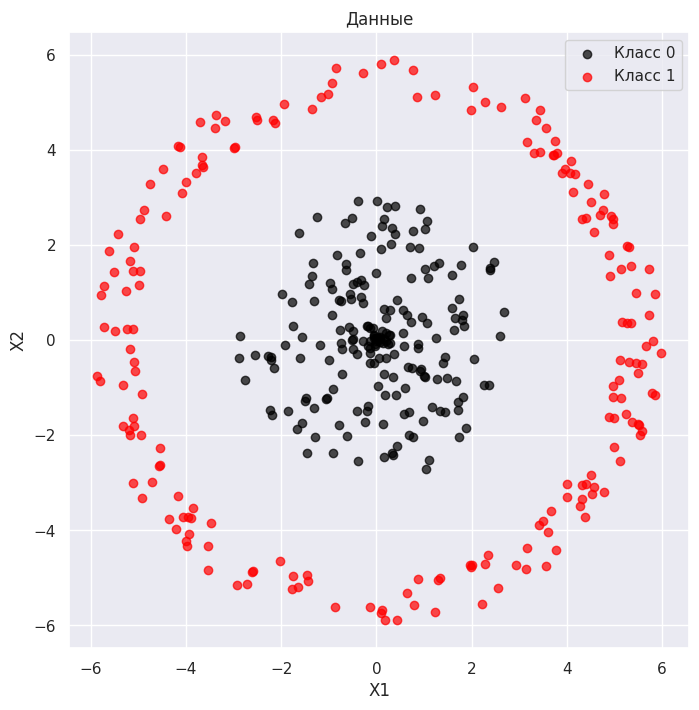

In [140]:
#Ваш код здесь

np.random.seed(42)
n = 200

# Класс 0: точки внутри круга радиуса 3
r = 3
theta = np.random.uniform(0, 2*np.pi, n)
r1 = np.random.uniform(0, r, n)
X_1 = np.column_stack([r1 * np.cos(theta), r1 * np.sin(theta)])
y_1 = np.zeros(n)

# Класс 1: точки в кольце между радиусами 5 и 6
r_min, r_max = 5, 6
theta = np.random.uniform(0, 2*np.pi, n)
r2 = np.random.uniform(r_min, r_max, n)
X_2 = np.column_stack([r2 * np.cos(theta), r2 * np.sin(theta)])
y_2 = np.ones(n)

X = np.vstack([X_1, X_2])
y = np.hstack([y_1, y_2])

plt.figure(figsize=(8, 8))
plt.scatter(X_1[:, 0], X_1[:, 1], color='black', label='Класс 0', alpha=0.7)
plt.scatter(X_2[:, 0], X_2[:, 1], color='red', label='Класс 1', alpha=0.7)
plt.title('Данные')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

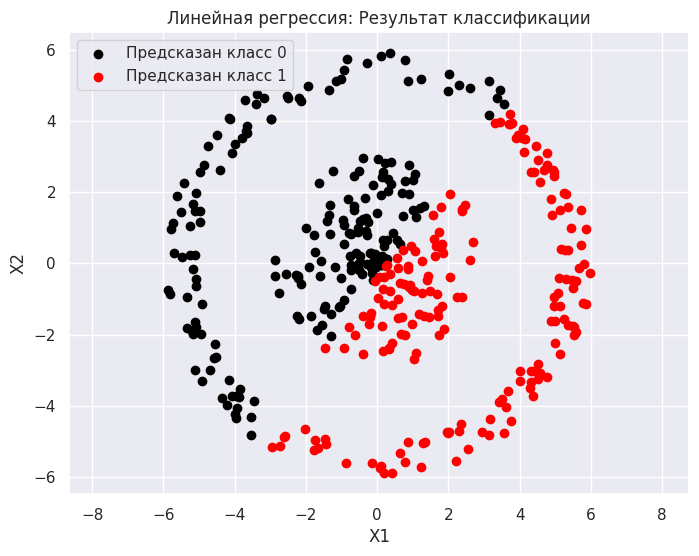

In [141]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X, y)

y_pred = reg.predict(X)
y_pred_class = (y_pred > 0.5).astype(int)

plt.figure(figsize=(8, 6))
plt.scatter(X[y_pred_class == 0][:, 0], X[y_pred_class == 0][:, 1], color='black', label='Предсказан класс 0')
plt.scatter(X[y_pred_class == 1][:, 0], X[y_pred_class == 1][:, 1], color='red', label='Предсказан класс 1')
plt.title('Линейная регрессия: Результат классификации')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

### <font color='DarkOrange'>**Задание 6 [2 баллa]**</font>

Приведите искусственный пример (можно даже очень неправдоподобный), когда линейная регрессия с $l_2$ регуляризацией гарантированно занулит какой-нибудь признак? Покажите (теоретически или программно), что признак действительно зануляется


In [142]:
# ваш код здесь

np.random.seed(123)
n = 1000
X1 = np.random.normal(0, 1, n)
X2 = np.random.normal(0, 1, n)
X3 = np.ones(n)
y = 3 * X1 + 2 * X2

X = np.column_stack([X1, X2, X3])

ridge = Ridge(alpha=1e6)
ridge.fit(X, y)

print(f"w1 (X1): {ridge.coef_[0]:.10f}")
print(f"w2 (X2): {ridge.coef_[1]:.10f}")
print(f"w3 (X3): {ridge.coef_[2]:.10f}")

print(f"\nПризнак X3 занулен: {np.abs(ridge.coef_[2]) < 1e-10}")

w1 (X1): 0.0029418460
w2 (X2): 0.0017440718
w3 (X3): 0.0000000000

Признак X3 занулен: True


<font color='MediumOrchid'>**Ваши выводы тут:**</font>
Один из признаков == константа, дублирующий смещение b => избыточный. Даём большое значение альфа, он зануляется, в отличае от остальных весов.

**Выводы** В первой части задания по линейным моделям мы должны были узнать:
.

1.   Зачем нужна регуляризация.
2.   Как отбирать значащие признаки.
3.   Когда линейные модели работают хорошо, а когда плохо

-----
<font color="white" style="opacity:0.2025"></font>

Во **второй части** мы будем применять линейные модели для классификации реальных данных, где мы сможем проверить наши выводы, полученные на искуственных примерах. А также убедимся в полезности нормировки и научимся работать с разными видами данных.
